In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/predicted_k562_regulator_knockout_gosai_Ns.csv")
pred_500_rc = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/predicted_k562_regulator_knockout_gosai_Ns_rc.csv")

### Read the prediction dfs and calculate ref-alt for each offset and average for the same motifs

In [3]:
pred_500['allele'] = pred_500['motif_name'].str.extract(r"_(ref|alt)")
pred_500['motif_group'] = pred_500['motif_name'].str.replace(r'_alt$', '', regex=True)
merged_df_ref = pred_500[pred_500['allele'] != 'alt'].copy()
merged_df_alt = pred_500[pred_500['allele'] == 'alt'].copy()

merged_df_ref = merged_df_ref.rename(columns={col: f"ref_{col}" for col in merged_df_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
merged_df_alt = merged_df_alt.rename(columns={col: f"alt_{col}" for col in merged_df_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(merged_df_ref, merged_df_alt, on=['seq_id', 'motif_group'], how='inner')

offsets=range(-80,81)

for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


/tmp/ipykernel_558106/3266570521.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_558106/3266570521.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_558106/3266570521.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

In [4]:
pred_500_rc['allele'] = pred_500_rc['motif_name'].str.extract(r"_(ref|alt)")
pred_500_rc['motif_group'] = pred_500_rc['motif_name'].str.replace(r'_alt$', '', regex=True)
merged_df_rc_ref = pred_500_rc[pred_500_rc['allele'] != 'alt'].copy()
merged_df_rc_alt = pred_500_rc[pred_500_rc['allele'] == 'alt'].copy()


merged_df_rc_ref = merged_df_rc_ref.rename(columns={col: f"ref_{col}" for col in merged_df_rc_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
merged_df_rc_alt = merged_df_rc_alt.rename(columns={col: f"alt_{col}" for col in merged_df_rc_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df_rc = pd.merge(merged_df_rc_ref, merged_df_rc_alt, on=['seq_id', 'motif_group'], how='inner')

offsets=range(-80,81)

for offset in offsets:
    merged_df_rc[f'diff_{offset}'] =  merged_df_rc[f'ref_predicted_{offset}'] - merged_df_rc[f'alt_predicted_{offset}']

avg_diff_rc = merged_df_rc.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


/tmp/ipykernel_558106/566219730.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_rc[f'diff_{offset}'] =  merged_df_rc[f'ref_predicted_{offset}'] - merged_df_rc[f'alt_predicted_{offset}']
/tmp/ipykernel_558106/566219730.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_rc[f'diff_{offset}'] =  merged_df_rc[f'ref_predicted_{offset}'] - merged_df_rc[f'alt_predicted_{offset}']
/tmp/ipykernel_558106/566219730.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

### For the forward df, you have to swap the signs

In [5]:
updated_columns = []

for col in avg_diff.columns:
    if col.startswith("diff_"):  
        value = int(col.split("_")[1]) 
        if value < 0:
            updated_columns.append(f"{-value}")  
        elif value > 0:
            updated_columns.append(f"{-value}")  
        else:
            updated_columns.append(f"{value}")  
    else:
        updated_columns.append(col)  

avg_diff.columns = updated_columns

print(avg_diff.columns)

Index(['motif_group', '80', '79', '78', '77', '76', '75', '74', '73', '72',
       ...
       '-71', '-72', '-73', '-74', '-75', '-76', '-77', '-78', '-79', '-80'],
      dtype='object', length=162)


### Dont swap the signs for the rev columns

In [6]:
updated_columns = []

for col in avg_diff_rc.columns:
    if col.startswith("diff_"):  
        value = int(col.split("_")[1])  
        if value < 0:
            updated_columns.append(f"{value}")  
        elif value > 0:
            updated_columns.append(f"{value}") 
        else:
            updated_columns.append(f"{value}") 
    else:
        updated_columns.append(col)  

avg_diff_rc.columns = updated_columns

print(avg_diff_rc.columns)

Index(['motif_group', '-80', '-79', '-78', '-77', '-76', '-75', '-74', '-73',
       '-72',
       ...
       '71', '72', '73', '74', '75', '76', '77', '78', '79', '80'],
      dtype='object', length=162)


### sort the dfs

In [7]:
pos_cols = [col for col in avg_diff.columns if col != 'motif_group']
pos_cols_int = [int(c) for c in pos_cols]
pos_cols_sorted = sorted(pos_cols_int)
pos_cols_sorted_str = [str(c) for c in pos_cols_sorted]
new_col_order = ['motif_group'] + pos_cols_sorted_str
avg_diff = avg_diff[new_col_order]
print(avg_diff.columns)

Index(['motif_group', '-80', '-79', '-78', '-77', '-76', '-75', '-74', '-73',
       '-72',
       ...
       '71', '72', '73', '74', '75', '76', '77', '78', '79', '80'],
      dtype='object', length=162)


In [8]:
pos_cols = [col for col in avg_diff_rc.columns if col != 'motif_group']
pos_cols_int = [int(c) for c in pos_cols]
pos_cols_sorted = sorted(pos_cols_int)
pos_cols_sorted_str = [str(c) for c in pos_cols_sorted]
new_col_order = ['motif_group'] + pos_cols_sorted_str
avg_diff_rc = avg_diff_rc[new_col_order]
print(avg_diff_rc.columns)

Index(['motif_group', '-80', '-79', '-78', '-77', '-76', '-75', '-74', '-73',
       '-72',
       ...
       '71', '72', '73', '74', '75', '76', '77', '78', '79', '80'],
      dtype='object', length=162)


### drop the mouse TFs

In [9]:
avg_diff = avg_diff[~avg_diff['motif_group'].str.contains("Mouse", case=False, na=False)]
avg_diff_rc = avg_diff_rc[~avg_diff_rc['motif_group'].str.contains("Mouse", case=False, na=False)]

### Join and sort the dfs

In [10]:
avg_diff.head(5)

,motif_group,-80,-79,-78,-77,-76,-75,-74,-73,-72,...,71,72,73,74,75,76,77,78,79,80
0,Arid3a_MA0151.1,-0.109137,-0.107680,-0.124950,-0.128151,-0.130990,-0.130945,-0.135162,-0.139085,-0.144613,...,-0.291751,-0.285006,-0.283363,-0.280713,-0.279054,-0.285873,-0.275623,-0.276163,-0.278607,-0.281399
1,CTCFL_HUMAN.H11MO.0.A,1.955860,1.979977,1.992774,2.005451,2.017908,2.030635,2.045176,2.057760,2.082023,...,2.658260,2.633503,2.636840,2.629080,2.596603,2.594883,2.595752,2.566370,2.557253,2.529137
2,EGR1_C2H2_1,0.308467,0.301612,0.296645,0.305787,0.299794,0.296346,0.310916,0.306863,0.314352,...,0.565669,0.554302,0.563849,0.547769,0.544768,0.535033,0.527222,0.525487,0.513980,0.517630
3,EGR1_HUMAN.H11MO.0.A,0.472290,0.445875,0.457118,0.455714,0.454361,0.447332,0.464778,0.461911,0.462130,...,0.766827,0.765606,0.760836,0.752747,0.753516,0.764025,0.759610,0.760047,0.745541,0.763352
4,EWSR1-FLI1_MA0149.1,0.039418,0.033813,0.028678,0.025717,0.027543,0.022930,0.024403,0.027740,0.031655,...,-0.054691,-0.063774,-0.057908,-0.052205,-0.065258,-0.070861,-0.065363,-0.067033,-0.071583,-0.077301


In [11]:
avg_diff_rc.head(5)

,motif_group,-80,-79,-78,-77,-76,-75,-74,-73,-72,...,71,72,73,74,75,76,77,78,79,80
0,Arid3a_MA0151.1,-0.101354,-0.112328,-0.112858,-0.114700,-0.122882,-0.119304,-0.129700,-0.117593,-0.128584,...,-0.257999,-0.258769,-0.261773,-0.257206,-0.253118,-0.258495,-0.261199,-0.253722,-0.266936,-0.267004
1,CTCFL_HUMAN.H11MO.0.A,1.527170,1.529808,1.521797,1.552699,1.545280,1.554748,1.563079,1.568300,1.562310,...,2.232630,2.204175,2.200784,2.186991,2.192406,2.159590,2.166657,2.152040,2.162054,2.133579
2,EGR1_C2H2_1,0.102196,0.102724,0.095289,0.089664,0.089638,0.081899,0.085284,0.082429,0.078046,...,0.136438,0.139427,0.145773,0.149359,0.140014,0.146668,0.148283,0.152758,0.161955,0.172343
3,EGR1_HUMAN.H11MO.0.A,0.692863,0.706155,0.710482,0.713698,0.688977,0.689984,0.685452,0.691608,0.689324,...,0.935360,0.924852,0.919854,0.917957,0.901740,0.911920,0.899858,0.880467,0.900537,0.895307
4,EWSR1-FLI1_MA0149.1,-0.028743,-0.036677,-0.038978,-0.040834,-0.053919,-0.046944,-0.062523,-0.048618,-0.048451,...,-0.076562,-0.083514,-0.079539,-0.082342,-0.082536,-0.079054,-0.082176,-0.074445,-0.066688,-0.068380


In [12]:
avg_diff = avg_diff.rename(columns={col: f"{col}_for" for col in avg_diff.columns if col != 'motif_group'})
avg_diff_rc = avg_diff_rc.rename(columns={col: f"{col}_revcomp" for col in avg_diff_rc.columns if col != 'motif_group'})

### Perform the scaling

In [13]:
for_columns = [col for col in avg_diff.columns if col.endswith('_for')]
avg_diff[for_columns] = avg_diff[for_columns].div(avg_diff[for_columns].abs().max(axis=1), axis=0)

In [14]:
revcomp_columns = [col for col in avg_diff_rc.columns if col.endswith('_revcomp')]
avg_diff_rc[revcomp_columns] = avg_diff_rc[revcomp_columns].div(avg_diff_rc[revcomp_columns].abs().max(axis=1), axis=0)

In [15]:
merged_df = pd.merge(avg_diff, avg_diff_rc, on='motif_group')
merged_df.head(5)

,motif_group,-80_for,-79_for,-78_for,-77_for,-76_for,-75_for,-74_for,-73_for,-72_for,...,71_revcomp,72_revcomp,73_revcomp,74_revcomp,75_revcomp,76_revcomp,77_revcomp,78_revcomp,79_revcomp,80_revcomp
0,Arid3a_MA0151.1,-0.347677,-0.343034,-0.398050,-0.408247,-0.417293,-0.417150,-0.430583,-0.443081,-0.460691,...,-0.892118,-0.894778,-0.905165,-0.889375,-0.875237,-0.893830,-0.903181,-0.877327,-0.923018,-0.923255
1,CTCFL_HUMAN.H11MO.0.A,0.706610,0.715323,0.719946,0.724526,0.729026,0.733624,0.738878,0.743424,0.752190,...,0.984609,0.972060,0.970564,0.964482,0.966870,0.952397,0.955514,0.949068,0.953484,0.940927
2,EGR1_C2H2_1,0.519287,0.507747,0.499385,0.514775,0.504685,0.498882,0.523408,0.516585,0.529194,...,0.791664,0.809007,0.845829,0.866636,0.812417,0.851022,0.860393,0.886358,0.939727,1.000000
3,EGR1_HUMAN.H11MO.0.A,0.584485,0.551795,0.565709,0.563972,0.562297,0.553598,0.575189,0.571640,0.571912,...,0.938613,0.928069,0.923054,0.921150,0.904877,0.915092,0.902988,0.883530,0.903670,0.898421
4,EWSR1-FLI1_MA0149.1,0.509926,0.437426,0.370996,0.332685,0.356315,0.296628,0.315684,0.358858,0.409498,...,-0.508712,-0.554903,-0.528491,-0.547117,-0.548410,-0.525267,-0.546017,-0.494647,-0.443109,-0.454347


### Plot

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


all_columns = merged_df.columns.tolist()
print(all_columns)
position_columns = []

# Find forward columns (-80_for to 80_for)
for i in range(-80, 81):
    col_name = f"{i}_for"
    if col_name in all_columns:
        position_columns.append(col_name)

# Find reverse complement columns (-80_revcomp to 80_revcomp)  
for i in range(-80, 81):
    col_name = f"{i}_revcomp"
    if col_name in all_columns:
        position_columns.append(col_name)

print(f"Found {len(position_columns)} position columns for clustering")
print(f"Forward columns: {len([col for col in position_columns if col.endswith('_for')])}")
print(f"Revcomp columns: {len([col for col in position_columns if col.endswith('_revcomp')])}")

['motif_group', '-80_for', '-79_for', '-78_for', '-77_for', '-76_for', '-75_for', '-74_for', '-73_for', '-72_for', '-71_for', '-70_for', '-69_for', '-68_for', '-67_for', '-66_for', '-65_for', '-64_for', '-63_for', '-62_for', '-61_for', '-60_for', '-59_for', '-58_for', '-57_for', '-56_for', '-55_for', '-54_for', '-53_for', '-52_for', '-51_for', '-50_for', '-49_for', '-48_for', '-47_for', '-46_for', '-45_for', '-44_for', '-43_for', '-42_for', '-41_for', '-40_for', '-39_for', '-38_for', '-37_for', '-36_for', '-35_for', '-34_for', '-33_for', '-32_for', '-31_for', '-30_for', '-29_for', '-28_for', '-27_for', '-26_for', '-25_for', '-24_for', '-23_for', '-22_for', '-21_for', '-20_for', '-19_for', '-18_for', '-17_for', '-16_for', '-15_for', '-14_for', '-13_for', '-12_for', '-11_for', '-10_for', '-9_for', '-8_for', '-7_for', '-6_for', '-5_for', '-4_for', '-3_for', '-2_for', '-1_for', '0_for', '1_for', '2_for', '3_for', '4_for', '5_for', '6_for', '7_for', '8_for', '9_for', '10_for', '11_for', '12

In [17]:
merged_df

,motif_group,-80_for,-79_for,-78_for,-77_for,-76_for,-75_for,-74_for,-73_for,-72_for,...,71_revcomp,72_revcomp,73_revcomp,74_revcomp,75_revcomp,76_revcomp,77_revcomp,78_revcomp,79_revcomp,80_revcomp
0,Arid3a_MA0151.1,-0.347677,-0.343034,-0.398050,-0.408247,-0.417293,-0.417150,-0.430583,-0.443081,-0.460691,...,-0.892118,-0.894778,-0.905165,-0.889375,-0.875237,-0.893830,-0.903181,-0.877327,-0.923018,-0.923255
1,CTCFL_HUMAN.H11MO.0.A,0.706610,0.715323,0.719946,0.724526,0.729026,0.733624,0.738878,0.743424,0.752190,...,0.984609,0.972060,0.970564,0.964482,0.966870,0.952397,0.955514,0.949068,0.953484,0.940927
2,EGR1_C2H2_1,0.519287,0.507747,0.499385,0.514775,0.504685,0.498882,0.523408,0.516585,0.529194,...,0.791664,0.809007,0.845829,0.866636,0.812417,0.851022,0.860393,0.886358,0.939727,1.000000
3,EGR1_HUMAN.H11MO.0.A,0.584485,0.551795,0.565709,0.563972,0.562297,0.553598,0.575189,0.571640,0.571912,...,0.938613,0.928069,0.923054,0.921150,0.904877,0.915092,0.902988,0.883530,0.903670,0.898421
4,EWSR1-FLI1_MA0149.1,0.509926,0.437426,0.370996,0.332685,0.356315,0.296628,0.315684,0.358858,0.409498,...,-0.508712,-0.554903,-0.528491,-0.547117,-0.548410,-0.525267,-0.546017,-0.494647,-0.443109,-0.454347
5,FOXC1_forkhead_1,0.294111,0.280929,0.244669,0.231261,0.206716,0.182349,0.168737,0.143434,0.141139,...,-0.714141,-0.691962,-0.674595,-0.683549,-0.684166,-0.683694,-0.693451,-0.643598,-0.661110,-0.675305
6,FOXO1_forkhead_2,0.894850,0.855825,0.798387,0.779735,0.747358,0.675861,0.675740,0.661771,0.628635,...,-0.706193,-0.663650,-0.640177,-0.594635,-0.620296,-0.612212,-0.620117,-0.602915,-0.569711,-0.566614
7,FOXO1_forkhead_3,-0.409089,-0.414184,-0.440032,-0.438666,-0.452933,-0.443037,-0.445374,-0.446133,-0.458679,...,-0.910204,-0.925313,-0.912749,-0.909196,-0.928793,-0.934617,-0.930825,-0.893712,-0.898173,-0.933869
8,GATA1+TAL1_MA0140.2,0.900307,0.862652,0.860180,0.844293,0.838665,0.846823,0.837176,0.832192,0.836595,...,0.941395,0.942117,0.946831,0.961630,0.954375,0.966962,0.971040,0.969864,0.983992,1.000000
9,IKZF1_HUMAN.H11MO.0.C,-0.544911,-0.546692,-0.589731,-0.589430,-0.615102,-0.596860,-0.607193,-0.604071,-0.606436,...,-0.907110,-0.927816,-0.935102,-0.905989,-0.923943,-0.932547,-0.949946,-0.932520,-0.921232,-0.939211


Plotting Forward clustermap...
Index(['motif_group', '-80_for', '-79_for', '-78_for', '-77_for', '-76_for',
       '-75_for', '-74_for', '-73_for', '-72_for',
       ...
       '71_for', '72_for', '73_for', '74_for', '75_for', '76_for', '77_for',
       '78_for', '79_for', '80_for'],
      dtype='object', length=162)
['-80_for', '-79_for', '-78_for', '-77_for', '-76_for', '-75_for', '-74_for', '-73_for', '-72_for', '-71_for', '-70_for', '-69_for', '-68_for', '-67_for', '-66_for', '-65_for', '-64_for', '-63_for', '-62_for', '-61_for', '-60_for', '-59_for', '-58_for', '-57_for', '-56_for', '-55_for', '-54_for', '-53_for', '-52_for', '-51_for', '-50_for', '-49_for', '-48_for', '-47_for', '-46_for', '-45_for', '-44_for', '-43_for', '-42_for', '-41_for', '-40_for', '-39_for', '-38_for', '-37_for', '-36_for', '-35_for', '-34_for', '-33_for', '-32_for', '-31_for', '-30_for', '-29_for', '-28_for', '-27_for', '-26_for', '-25_for', '-24_for', '-23_for', '-22_for', '-21_for', '-20_for', '-19_for'

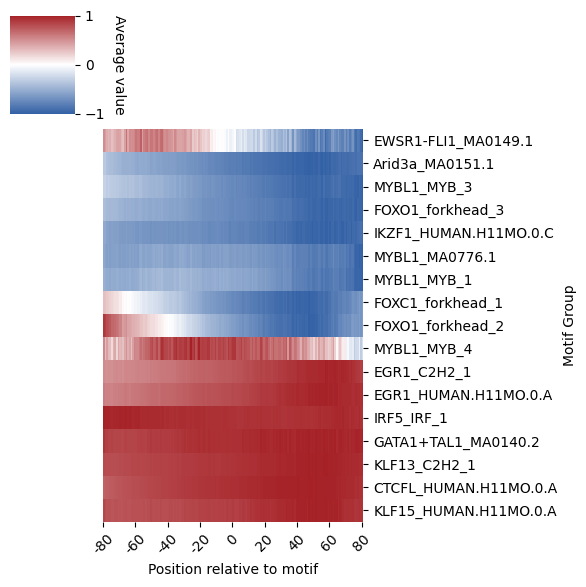

Plotting Reverse clustermap...
Index(['motif_group', '-80_revcomp', '-79_revcomp', '-78_revcomp',
       '-77_revcomp', '-76_revcomp', '-75_revcomp', '-74_revcomp',
       '-73_revcomp', '-72_revcomp',
       ...
       '71_revcomp', '72_revcomp', '73_revcomp', '74_revcomp', '75_revcomp',
       '76_revcomp', '77_revcomp', '78_revcomp', '79_revcomp', '80_revcomp'],
      dtype='object', length=162)
['-80_revcomp', '-79_revcomp', '-78_revcomp', '-77_revcomp', '-76_revcomp', '-75_revcomp', '-74_revcomp', '-73_revcomp', '-72_revcomp', '-71_revcomp', '-70_revcomp', '-69_revcomp', '-68_revcomp', '-67_revcomp', '-66_revcomp', '-65_revcomp', '-64_revcomp', '-63_revcomp', '-62_revcomp', '-61_revcomp', '-60_revcomp', '-59_revcomp', '-58_revcomp', '-57_revcomp', '-56_revcomp', '-55_revcomp', '-54_revcomp', '-53_revcomp', '-52_revcomp', '-51_revcomp', '-50_revcomp', '-49_revcomp', '-48_revcomp', '-47_revcomp', '-46_revcomp', '-45_revcomp', '-44_revcomp', '-43_revcomp', '-42_revcomp', '-41_revcomp

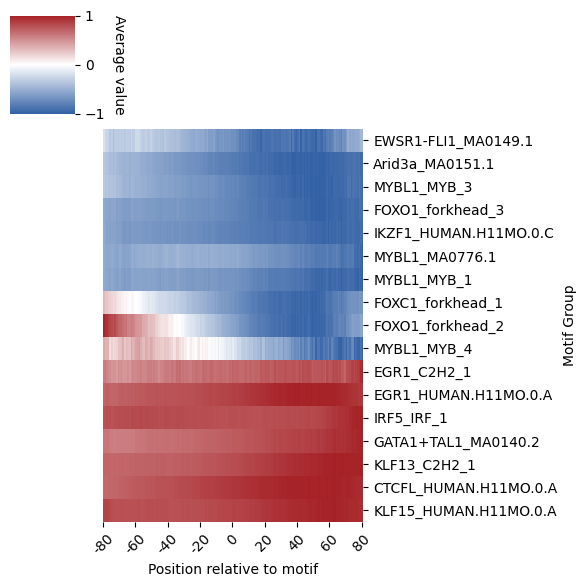


Hierarchical clustering completed!
Number of motif groups clustered: 17
First 10 motifs in order: ['EWSR1-FLI1_MA0149.1', 'Arid3a_MA0151.1', 'MYBL1_MYB_3', 'FOXO1_forkhead_3', 'IKZF1_HUMAN.H11MO.0.C', 'MYBL1_MA0776.1', 'MYBL1_MYB_1', 'FOXC1_forkhead_1', 'FOXO1_forkhead_2', 'MYBL1_MYB_4']


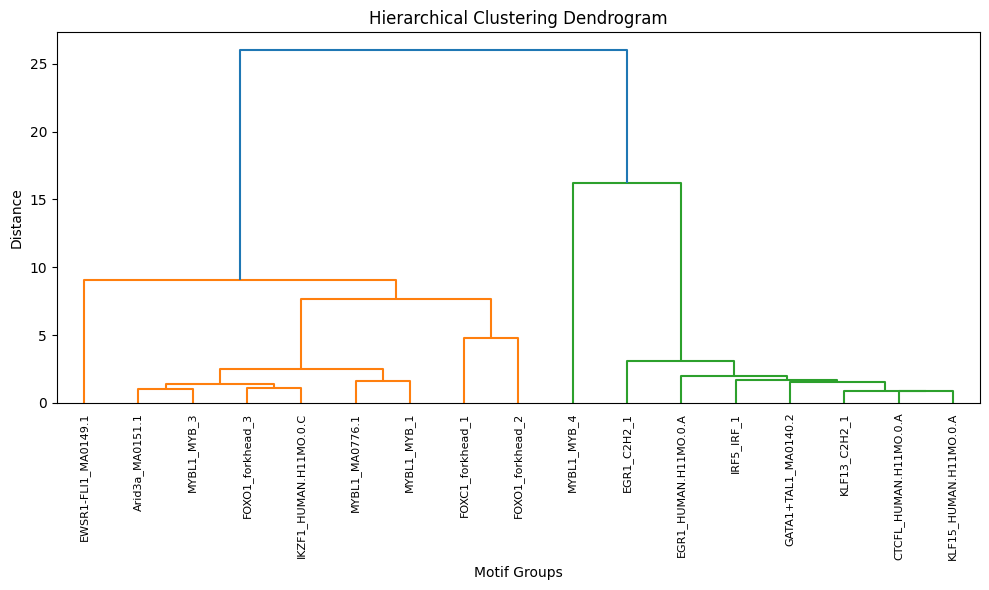

In [18]:
cluster_data = merged_df.set_index('motif_group')[position_columns].fillna(0)

# Step 3: Perform hierarchical clustering
row_distances = pdist(cluster_data, metric='euclidean')
row_linkage = linkage(row_distances, method='average')

# Get the row ordering from hierarchical clustering
row_order_indices = leaves_list(row_linkage)
motif_order = cluster_data.index[row_order_indices]

# Step 4: Custom colormap setup
vmin, vmax = -1, 1
white_pos = - vmin / (vmax - vmin)

colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, "#ffffff"),  # white at 0
    (1.0, "#A52126")         # dark red at max
]

cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Step 5: Plotting function
def plot_hierarchical_clustermap(df, title, motif_order, orientation, save_path=None):
    # Get position columns for this orientation
    if orientation == "forward":
        suffix = "_for"
    else:  # reverse
        suffix = "_revcomp"
    
    print(df.columns)
    position_cols = [col for col in df.columns if col.endswith(suffix)]
    print(position_cols)
    try:
        position_cols.sort(key=lambda x: int(x.replace(suffix, '')))
    except:
        pass  # If sorting fails, use original order
    
    try:
        positions = np.array([int(col.replace(suffix, '')) for col in position_cols])
        xticks_positions = np.arange(-80, 81, 20)
        xticks_indices = []
        for pos in xticks_positions:
            pos_matches = np.where(positions == pos)[0]
            if len(pos_matches) > 0:
                xticks_indices.append(pos_matches[0])
        
        # If no standard positions found, use evenly spaced indices
        if len(xticks_indices) == 0:
            n_ticks = min(9, len(position_cols))
            xticks_indices = np.linspace(0, len(position_cols)-1, n_ticks, dtype=int)
            xticks_positions = [positions[i] for i in xticks_indices]
            
    except Exception as e:
        print(f"Position parsing failed: {e}")
    
    # Create data matrix
    data_matrix = df.set_index('motif_group')[position_cols]
    
    # Reorder rows according to hierarchical clustering
    data_matrix_ordered = data_matrix.reindex(motif_order)
    
    # Plot clustermap
    g = sns.clustermap(
        data_matrix_ordered,
        cmap=cmap,
        row_cluster=False,  # Use our pre-computed hierarchical order
        col_cluster=False,  # Keep positions in original order
        figsize=(6, max(6, len(data_matrix_ordered) * 0.75 * 0.15)),
        yticklabels=True,
        xticklabels=False,
        vmin=vmin,
        vmax=vmax,
    )
    
    # Set x-axis ticks manually
    g.ax_heatmap.set_xticks(xticks_indices)
    g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)
    
    g.ax_heatmap.set_xlabel("Position relative to motif")
    g.ax_heatmap.set_ylabel("Motif Group")
    
    # Setup colorbar
    cbar = g.cax
    cbar.set_yticks([-1.0, 0, 1.0])
    cbar.set_ylabel("Average value", rotation=270, labelpad=15)
    
    plt.tight_layout()
    
    if save_path:
        # plt.savefig(save_path, dpi=600, bbox_inches='tight')
        plt.savefig(save_path, format="svg")

    
    plt.show()
    
    return g

# Step 6: Plot both clustermaps
print("Plotting Forward clustermap...")
g1 = plot_hierarchical_clustermap(
    avg_diff, 
    "Forward",
    motif_order,
    "forward",
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_forward_hierarchical_Ns.svg"
)

print("Plotting Reverse clustermap...")
g2 = plot_hierarchical_clustermap(
    avg_diff_rc, 
    "Reverse",
    motif_order,
    "reverse",
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_reverse_hierarchical_Ns.svg"
)

# Optional: Print clustering information
print(f"\nHierarchical clustering completed!")
print(f"Number of motif groups clustered: {len(motif_order)}")
print(f"First 10 motifs in order: {list(motif_order[:10])}")

# Optional: Plot dendrogram
plt.figure(figsize=(10, 6))
from scipy.cluster.hierarchy import dendrogram
dendrogram(row_linkage, labels=cluster_data.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Motif Groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/hierarchical_dendrogram_Ns.svg", format="svg")
plt.show()

In [19]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap
# import numpy as np

# # Positions as integers for x labels
# position_cols = [col for col in avg_diff.columns if col != 'motif_group']
# positions = np.array(list(map(int, position_cols)))
# xticks_positions = np.arange(-80, 81, 20)
# xticks_indices = [np.where(positions == pos)[0][0] for pos in xticks_positions if pos in positions]

# # Custom colormap with white at 0
# from matplotlib.colors import LinearSegmentedColormap

# vmin, vmax = -0.5, 3
# white_pos = -vmin / (vmax - vmin)  # 0 maps to white

# # Make a colormap with explicit positions
# colors = [
#     (0.0, "#3361A5"),        # dark blue at min
#     (white_pos, "#ffffff"),  # white at 0
#     (1.0, "#A52126")         # dark red at max
# ]

# cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)


# # Full data matrix
# data_matrix = avg_diff.set_index('motif_group')[position_cols]

# # Plot clustermap with row clustering
# g = sns.clustermap(
#     data_matrix,
#     cmap=cmap,
#     row_cluster=True,
#     col_cluster=False,        # keep positions in original order
#     figsize=(6, max(6, len(data_matrix) * 0.75 * 0.15)),
#     yticklabels=True,
#     xticklabels=False,
#     vmin=vmin,
#     vmax=vmax,
# )

# # Set x-axis ticks manually
# g.ax_heatmap.set_xticks(xticks_indices)
# g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

# g.ax_heatmap.set_xlabel("Position relative to motif")
# g.ax_heatmap.set_ylabel("Motif Group")
# # plt.title("Average Predicted Values Heatmap with Clustering", pad=50)

# # Adjust colorbar ticks to show min, zero, max
# cbar = g.cax
# # cbar_ticks = [-0.5, 0, 3]
# # g.cax.set_yticks([0, 0.5, 1])  # placeholder, will be adjusted by colorbar
# # g.cax.set_yticklabels(cbar_ticks)
# cbar = g.cax
# cbar.set_yticks([-0.5, 0, 3])
# cbar.set_ylabel("Average value", rotation=270, labelpad=15)
# # g.cax.set_ylabel("Average value", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(
#     "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_Ns.png",
#     dpi=600
# )
# plt.show()

#### I want to check what normalizing each row looks like

In [20]:
# # Row-wise normalization: divide by max absolute value of each row
# data_matrix_scaled = data_matrix.div(data_matrix.abs().max(axis=1), axis=0)

# # Now values are in [-1, 1]
# vmin, vmax = -1, 1

# colors = [
#     (0.0, "#3361A5"),   # dark blue at -1
#     (0.5, "#ffffff"),   # white at 0
#     (1.0, "#A52126")    # dark red at +1
# ]
# cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# # Plot clustermap with row clustering
# g = sns.clustermap(
#     data_matrix_scaled,
#     cmap=cmap,
#     row_cluster=True,
#     col_cluster=False,
#     figsize=(6, max(6, len(data_matrix_scaled) * 0.75 * 0.15)),
#     yticklabels=True,
#     xticklabels=False,
#     vmin=vmin,
#     vmax=vmax,
# )

# # X-axis ticks
# g.ax_heatmap.set_xticks(xticks_indices)
# g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

# g.ax_heatmap.set_xlabel("Motif Position")
# g.ax_heatmap.set_ylabel("Motif Group")
# # plt.title("Row-Normalized Predicted Values Heatmap (signed)", pad=50)

# # Colorbar
# cbar = g.cax
# cbar_ticks = [-1, 0, 1]
# cbar.set_yticks(cbar_ticks)       # positions in data scale
# cbar.set_yticklabels(cbar_ticks)
# # g.cax.set_ylabel("Scaled value (row-wise, signed)", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(
#     "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_row_scaled_signed.png",
#     dpi=600
# )
# plt.show()
